# EDA desde cero — Universo México (NutriMatch)

**Snapshot analizado:** `off_csv_20260919` (export CSV diario de Open Food Facts, filtrado a México con `countries_tags` conteniendo `en:mexico`; ver `datos/snapshots/off_csv_20260919/_metadata.json`).

**Universo:** 16.851 productos, 0 códigos duplicados, 0 filas rechazadas por malformación en la ingesta (`scripts/ingesta_off.py`).

**Fecha de ejecución de este análisis:** 2026-09-20.

**Objetivo:** confirmar o refutar sobre el universo real la baselina de la sección 7.2 del documento maestro (que provenía de una muestra de 5.803 productos en 32 categorías elegidas a mano, por lo tanto no representativa) y responder los checkpoints obligatorios de la sección 7.7. Ninguna cifra de este notebook se supone: todas se calculan en las celdas de código, sobre el snapshot citado arriba.

**Regla de trabajo:** un campo que existe en Open Food Facts no se asume completo por el hecho de existir. Toda cobertura se reporta como porcentaje sobre el universo total (`n = 16.851`), nunca sobre el subconjunto de quienes ya tenían el dato.

**Aviso:** este notebook es de diagnóstico de datos. No contiene evaluación médica ni recomendaciones de compra; eso es responsabilidad de `src/nutrimatch/engine`, que todavía no existe.

---


In [ ]:
"""Configuración e ingesta del snapshot.

Este notebook usa DuckDB para consultar el Parquet directamente, sin cargarlo
completo en memoria salvo cuando el resultado ya es una tabla pequeña (por
ejemplo, una tabla de coberturas de 20 filas). El paquete `nutrimatch` se
importa para dejar constancia de que el motor y el notebook comparten el mismo
código (decisión 14); todavía no expone funciones de EDA porque el análisis
va primero y las decisiones de transformación se toman después.
"""

import json
from pathlib import Path

import duckdb
import pandas as pd

import nutrimatch

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SNAPSHOT_ID = "off_csv_20260919"
PARQUET_PATH = REPO_ROOT / "datos" / "procesados" / "off_mexico_20260919.parquet"
META_PATH = REPO_ROOT / "datos" / "snapshots" / SNAPSHOT_ID / "_metadata.json"

pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 120)

con = duckdb.connect()
P = str(PARQUET_PATH)  # se interpola en las consultas SQL de este notebook

metadata = json.loads(META_PATH.read_text(encoding="utf-8"))
N = con.execute(f"SELECT count(*) FROM '{P}'").fetchone()[0]

print(f"nutrimatch versión: {nutrimatch.__version__}")
print(f"snapshot_id: {metadata['snapshot_id']}")
print(f"generado_en: {metadata['generado_en']}")
print(f"fuente export: {metadata['procedencia']['url']}")
print(f"sha256 export: {metadata['procedencia']['sha256'][:16]}…")
print(f"reconciliación vs API ({metadata['reconciliacion']['fecha_count_api']}): "
      f"export={metadata['reconciliacion']['filas_export']:,} vs "
      f"API={metadata['reconciliacion']['count_api']:,} "
      f"(Δ={metadata['reconciliacion']['delta']:+,}, "
      f"{metadata['reconciliacion']['desviacion_relativa']:.1%})")
print(f"\nUniverso cargado: N = {N:,} productos")

## 1. Cobertura de campos: universo real vs. baselina de muestra (sección 7.2)

La baselina de 7.2 se construyó recorriendo 32 categorías elegidas a mano, así que por definición el 100 % de esa muestra tenía categoría: eran los productos mejor documentados del catálogo. Aquí se recalcula la misma lista de campos sobre el universo completo, sin ese sesgo de selección.


In [ ]:
# Baselina de la sección 7.2, muestra de 5.803 productos, 2026-09-16.
# Se deja explícito con su fecha y tamaño muestral: es un punto de contraste,
# no una verdad a igualar.
BASELINA_7_2 = {
    "code": 100.0, "product_name": 97.3, "generic_name": 44.5, "brands": 96.4,
    "quantity": 91.9, "image_url": 99.5, "categories_tags": 100.0,
    "ingredients_text": 93.8, "ingredients_tags": 93.5, "additives_n": 93.8,
    "labels_tags": 91.5, "allergens": 61.7, "serving_size": 60.8,
    "nutriscore_grade": 85.0, "nova_group": 87.1,
    "energy-kcal_100g": 89.9, "fat_100g": 88.9, "saturated-fat_100g": 87.4,
    "carbohydrates_100g": 88.8, "sugars_100g": 87.4, "fiber_100g": 61.8,
    "proteins_100g": 88.8, "salt_100g": 87.7, "sodium_100g": 87.7,
    "added-sugars_100g": 90.1, "trans-fat_100g": 2.5, "cholesterol_100g": 3.7,
}


def cobertura(campo: str) -> int:
    """Cuenta filas con dato no nulo y no vacío (tras trim) en `campo`."""
    return con.execute(
        f'SELECT count(*) FROM \'{P}\' WHERE "{campo}" IS NOT NULL AND trim("{campo}") <> \'\''
    ).fetchone()[0]


campos_a_revisar = list(BASELINA_7_2.keys()) + [
    # Presentes en el export pero fuera de la baselina de 7.2: se reportan
    # igual para no repetir el error de asumir cobertura por existencia.
    "main_category", "traces", "ingredients_analysis_tags",
    "food_groups_tags", "nutrient_levels_tags", "data_quality_errors_tags",
]

filas = []
for campo in campos_a_revisar:
    n_con_dato = cobertura(campo)
    pct_real = round(n_con_dato * 100 / N, 1)
    pct_base = BASELINA_7_2.get(campo)
    filas.append({
        "campo": campo,
        "cobertura_real_%": pct_real,
        "n_con_dato": n_con_dato,
        "baselina_7.2_%": pct_base,
        "diferencia_pp": round(pct_real - pct_base, 1) if pct_base is not None else None,
    })

tabla_cobertura = pd.DataFrame(filas).sort_values("diferencia_pp")
tabla_cobertura

### Hallazgo 1 — la baselina de 7.2 queda refutada por sesgo de muestreo

Verificado el 2026-09-20 sobre N = 16.851: **todos los campos caen frente a la baselina**, y en los que dependen de tener categoría asignada la caída es de 40 a 65 puntos porcentuales: `categories_tags` pasa de 100 % a 51,8 %, `ingredients_text` de 93,8 % a 45,4 %, `labels_tags` de 91,5 % a 25,3 %, `allergens` de 61,7 % a 16,6 %. La única lectura consistente es que la muestra de 32 categorías estaba compuesta por los productos con mejor documentación de todo OFF México, no por una muestra representativa.

`nutriscore_grade` es la excepción aparente (99,2 % vs. 85,0 %): esa columna casi nunca está vacía porque OFF escribe el valor `"unknown"` cuando no puede calcularlo, en vez de dejar la celda en blanco. El dato real es que solo el 38,2 % trae un grado válido de la A a la E (ver sección 2); el resto son `unknown` (58,4 %) o `not-applicable` (2,6 %). Es un ejemplo directo de la regla de "no asumir que una variable está completa por el hecho de existir".

`trans-fat_100g` y `cholesterol_100g` confirman la sospecha de 7.7: 13,4 % y 13,1 % de cobertura respectivamente. Mejor que el 2,5 %/3,7 % de la muestra sesgada, pero igual insuficientes para ser dimensión puntuada del score.


## 2. Niveles de utilizabilidad: core3 / core5 / core7, NOVA, Nutri-Score, dieta

Definiciones (decisión 4 y sección 6 del documento maestro):
- **core3**: `energy-kcal_100g`, `proteins_100g`, `carbohydrates_100g`.
- **core5**: `energy-kcal_100g`, `fat_100g`, `saturated-fat_100g`, `sugars_100g`, `salt_100g`.
- **core7**: core5 + `carbohydrates_100g` + `proteins_100g`.
- **core7 + fibra**: core7 + `fiber_100g` (candidata a opcional/por categoría, ver checkpoint 7.7).


In [ ]:
def nn(campo: str) -> str:
    """Condición SQL: campo no nulo y no vacío tras trim."""
    return f'"{campo}" IS NOT NULL AND trim("{campo}") <> \'\''


def contar(condicion: str) -> int:
    return con.execute(f"SELECT count(*) FROM '{P}' WHERE {condicion}").fetchone()[0]


niveles = {
    "core3 (kcal, proteína, carbohidratos)": f'{nn("energy-kcal_100g")} AND {nn("proteins_100g")} AND {nn("carbohydrates_100g")}',
    "core5 (kcal, grasa, saturadas, azúcares, sal)": (
        f'{nn("energy-kcal_100g")} AND {nn("fat_100g")} AND {nn("saturated-fat_100g")} '
        f'AND {nn("sugars_100g")} AND {nn("salt_100g")}'
    ),
    "core7 (core5 + carbohidratos + proteína)": (
        f'{nn("energy-kcal_100g")} AND {nn("fat_100g")} AND {nn("saturated-fat_100g")} '
        f'AND {nn("carbohydrates_100g")} AND {nn("sugars_100g")} AND {nn("proteins_100g")} '
        f'AND {nn("salt_100g")}'
    ),
    "core7 + fibra": (
        f'{nn("energy-kcal_100g")} AND {nn("fat_100g")} AND {nn("saturated-fat_100g")} '
        f'AND {nn("carbohydrates_100g")} AND {nn("sugars_100g")} AND {nn("proteins_100g")} '
        f'AND {nn("salt_100g")} AND {nn("fiber_100g")}'
    ),
    "NOVA (con dato)": nn("nova_group"),
    "Nutri-Score válido (grado A–E)": "lower(nutriscore_grade) IN ('a','b','c','d','e')",
    "ingredients_analysis_tags (con dato, prerrequisito del filtro de dieta)": nn("ingredients_analysis_tags"),
    "  de los cuales: marcado vegano": "contains(lower(ingredients_analysis_tags),'en:vegan')",
    "  de los cuales: marcado vegetariano (incluye vegano)": "contains(lower(ingredients_analysis_tags),'en:vegetarian')",
}

filas = [{"nivel": k, "n": contar(v), "pct": round(contar(v) * 100 / N, 1)} for k, v in niveles.items()]
pd.DataFrame(filas)

### Hallazgo 2 — el universo "usable" es aproximadamente un tercio del catálogo, no 85-90 %

Verificado el 2026-09-20: core5 = 53,1 % (8.941 productos), core7 = 52,7 %, core7+fibra = 49,6 %. La fibra apenas resta 3,1 puntos porcentuales sobre core7, mucho menos diferencia de la que sugería la baselina — su exclusión selectiva por categoría (checkpoint 7.7) sigue siendo razonable pero ya no es urgente por volumen; se revisará por categoría en la sección 3 más abajo (D2) y cuando se construya `category_stats`.

NOVA cae a 40,2 % y Nutri-Score válido a 38,2 %, ambos muy por debajo del 87,1 % y 85,0 % de la baselina. La dieta declarable (vegano/vegetariano) depende de `ingredients_analysis_tags`, que solo existe en el 45,8 % de los productos: sobre esa base, sin ingredientes analizables la decisión 1 exige marcar "no verificable", no "no cumple". El 54,2 % restante del catálogo caería automáticamente en ese tercer estado para cualquier usuario con restricción de dieta.


## 3. Checkpoint D2 — poder discriminante de NOVA y relación con `additives_n`

Este checkpoint lo añadió el addendum del 2026-09-19: NOVA y el perfil nutricional (D1) no son ortogonales, y conviene medir si NOVA por sí solo distingue bien a los productos antes de aceptarlo como la dimensión completa de procesamiento (decisión 4: NOVA sí puntúa, Nutri-Score no).


In [ ]:
nova_additivos = con.execute(f"""
    SELECT
        coalesce(nullif(trim(nova_group), ''), '(sin dato)') AS nova,
        count(*) AS n_productos,
        round(count(*) * 100.0 / {N}, 1) AS pct_del_universo,
        count(*) FILTER (WHERE {nn("additives_n")}) AS con_additives_n,
        round(avg(try_cast(additives_n AS INT)) FILTER (WHERE {nn("additives_n")}), 2) AS additives_n_promedio
    FROM '{P}'
    GROUP BY 1
    ORDER BY 1
""").df()
nova_additivos

### Hallazgo 3 — NOVA discrimina poco por sí solo, pero `additives_n` lo refuerza sin duplicar el constructo

Verificado el 2026-09-20: de los 6.781 productos con NOVA, el 69,5 % (4.710) son grupo 4. Como subpuntaje aislado (`N1=100 … N4=0` según la sección 6), el 69,5 % de los productos evaluables recibiría 0 en D2, lo que le resta capacidad de ordenar.

`additives_n` tiene una relación monótona y fuerte con NOVA — promedio de aditivos 0,09 en N1, 0,13 en N2, 0,49 en N3 y 3,71 en N4 — y una cobertura ligeramente mayor (45,4 % vs. 40,2 %). No es un constructo distinto de "procesamiento": es una medida complementaria del mismo fenómeno con más granularidad dentro del grupo 4, donde NOVA solo. La combinación no duplica el constructo: NOVA es una clasificación de cuatro niveles y `additives_n` refina dentro de cada nivel, del mismo modo que D1 agrega varios nutrientes en una sola dimensión. La decisión quedó cerrada en A17 y la fórmula en A23: D2 usa NOVA como base y ajusta con `additives_n` dentro de la banda del grupo.


## 4. Alérgenos, trazas y sellos frontales oficiales de México

Tres checkpoints de 7.7 a la vez: cobertura real de alérgenos, cobertura real de los sellos `es:exceso-*`, y aquí se añade `traces` (menciones "puede contener"), que el export sí trae y que es indispensable para el filtro fail-safe de alergias de la decisión 1.


In [ ]:
checks = {
    "allergens (con dato, cualquier alérgeno declarado)": nn("allergens"),
    "traces (con dato, 'puede contener')": nn("traces"),
    "labels_tags (con dato, cualquier etiqueta)": nn("labels_tags"),
    "  de los cuales: algún sello es:exceso-*": "contains(lower(labels_tags),'es:exceso')",
    "  de los cuales: sello sistema-de-etiquetado-frontal": "contains(lower(labels_tags),'es:sistema-de-etiquetado')",
}
filas = [{"campo": k, "n": contar(v), "pct_del_universo": round(contar(v) * 100 / N, 1)} for k, v in checks.items()]
pd.DataFrame(filas)

### Hallazgo 4 — el fail-safe de alergias tal como está definido es inviable; los sellos confirman el rango bajo de 7.2/7.3

Verificado el 2026-09-20: `allergens` cubre 16,6 % (2.793 de 16.851), muy por debajo del 61,7 % de la baselina sesgada. `traces` cubre apenas 11,8 %. La decisión 1 dice: *"si no está verificado que NO contiene el alérgeno, se trata como no apto / requiere confirmación"*. Aplicado tal cual, un usuario con una alergia declarada vería el 83,4 % del catálogo marcado como no apto, sin que la mayoría de esos productos contenga realmente el alérgeno: es ausencia de dato, no presencia de riesgo. Ratifica la propuesta de tres estados que se planteó al inicio del proyecto (apto / no apto / no verificable), ahora con un número real detrás en vez de una intuición.

Los sellos frontales mexicanos caen dentro del rango que anticipaba la sección 7.3 (7–16 %): `es:exceso-*` cubre 7,1 % y `sistema-de-etiquetado-frontal` 7,9 %. Confirmado, no refutado.


## 5. `categories_tags` — el bloqueante de D1: política de categoría de referencia

D1 se define como percentil dentro de categoría (sección 6), pero `categories_tags` en OFF es multietiqueta y jerárquica: un mismo producto puede traer varias etiquetas a la vez, desde la más genérica hasta la más específica. Sin una regla explícita para elegir *una* categoría de referencia, el percentil de D1 no es computable. Esto es lo que hay que resolver aquí, con datos, no lo que se decidió de antemano.


In [ ]:
# Todas las etiquetas de categories_tags, explotadas una fila por etiqueta.
con.execute(f"""
    CREATE OR REPLACE TEMP TABLE todas_las_etiquetas AS
    SELECT code, unnest(str_split(categories_tags, ',')) AS etiqueta
    FROM '{P}' WHERE {nn("categories_tags")}
""")

con_categoria = con.execute("SELECT count(DISTINCT code) FROM todas_las_etiquetas").fetchone()[0]
print(f"Productos con al menos una etiqueta de categoría: {con_categoria:,} ({con_categoria*100/N:.1f}% del universo)\n")

print("Etiquetas más frecuentes (nivel más genérico o intermedio, no filtrado por posición):")
display(con.execute("""
    SELECT etiqueta, count(*) AS n_productos
    FROM todas_las_etiquetas GROUP BY 1 ORDER BY 2 DESC LIMIT 15
""").df())

n_etiquetas = con.execute("""
    SELECT round(avg(c), 2), max(c) FROM (
        SELECT code, count(*) c FROM todas_las_etiquetas GROUP BY 1
    )
""").fetchone()
print(f"\nEtiquetas de categoría por producto: media {n_etiquetas[0]}, máximo {n_etiquetas[1]}")

n_cat_distintas = con.execute("SELECT count(DISTINCT etiqueta) FROM todas_las_etiquetas").fetchone()[0]
tam_mediana = con.execute("""
    SELECT median(c) FROM (SELECT etiqueta, count(*) c FROM todas_las_etiquetas GROUP BY 1)
""").fetchone()[0]
print(f"Categorías distintas mencionadas (cualquier nivel): {n_cat_distintas:,}")
print(f"Tamaño mediano de una categoría (cualquier nivel): {tam_mediana} productos")

In [ ]:
# OFF ordena categories_tags de lo más genérico a lo más específico (regla
# documentada de su taxonomía). La última etiqueta de la lista es, por tanto,
# la candidata natural a "categoría de referencia": es la más específica que
# el producto declara.
con.execute(f"""
    CREATE OR REPLACE TEMP TABLE categoria_especifica AS
    SELECT code, str_split(categories_tags, ',')[-1] AS categoria
    FROM '{P}' WHERE {nn("categories_tags")}
""")

tamanos = con.execute("""
    SELECT categoria, count(*) AS tam FROM categoria_especifica GROUP BY 1
""").df()

con_cat = len(con.execute("SELECT DISTINCT code FROM categoria_especifica").df())
tabla = con.execute("""
    SELECT u.code, t.tam
    FROM categoria_especifica u
    JOIN (SELECT categoria, count(*) AS tam FROM categoria_especifica GROUP BY 1) t
      ON u.categoria = t.categoria
""").df()

for umbral in (5, 10, 20, 30, 50):
    bajo_umbral = (tabla["tam"] < umbral).sum()
    print(f"Productos cuya categoría más específica tiene menos de {umbral:>2d} miembros: "
          f"{bajo_umbral:,} ({bajo_umbral*100/con_cat:.1f}% de los que tienen categoría)")

print(f"\nCategorías distintas al nivel más específico: {tamanos.shape[0]:,}")
print(f"Tamaño mediano de la categoría específica de cada producto: {tabla['tam'].median():.0f}")
print(f"Tamaño máximo: {tabla['tam'].max():,}")

### Hallazgo 5 — la categoría más específica es demasiado fragmentada para calcular percentiles directamente

Verificado el 2026-09-20, sobre los 8.728 productos con categoría (51,8 % del universo): tomando la etiqueta más específica de cada producto (última posición en `categories_tags`, que es cómo OFF ordena su taxonomía, de lo genérico a lo específico), hay **2.088 categorías distintas** con un tamaño mediano de solo **14 productos**. El 29,1 % de los productos con categoría queda en una categoría específica de menos de 5 miembros, y el 40,8 % en menos de 10. Un percentil calculado sobre 4 productos no es una medida confiable.

En el otro extremo, usar cualquier etiqueta (sin filtrar por posición) concentra demasiado: `en:plant-based-foods-and-beverages` sola agrupa 3.048 productos, una sexta parte del universo con categoría, mezclando bebidas vegetales con snacks y cereales que tienen perfiles nutricionales muy distintos entre sí. Ninguno de los dos extremos —la más específica sin filtro, o la más genérica— sirve tal cual.

**Decisión A16, cerrada:** la categoría de referencia es la etiqueta más específica de `categories_tags`. Si esa categoría tiene menos de 30 productos, se sube un nivel y se repite la comprobación. El umbral de 30 cubre el 64,0 % de los productos con categoría específica sin retroceso. Si se agota la jerarquía sin alcanzar el mínimo, D1 queda sin dato para ese producto. No se imputa una categoría.


## 6. Consistencia interna de los datos

Checkpoints de 7.7: relación kJ↔kcal, relación sal↔sodio, azúcares mayores que carbohidratos, suma de macronutrientes mayor a 100 g, valores negativos. Se añade una comprobación de valores físicamente imposibles (energía por encima del máximo teórico de ~900 kcal/100 g, que corresponde a grasa pura).


In [ ]:
# --- kJ vs. kcal: factor de conversión estándar 1 kcal = 4.184 kJ ---
r = con.execute(f"""
    SELECT
        count(*) FILTER (WHERE {nn("energy_100g")} AND {nn("energy-kcal_100g")}) AS con_ambos,
        count(*) FILTER (
            WHERE {nn("energy_100g")} AND {nn("energy-kcal_100g")}
            AND abs(try_cast(energy_100g AS DOUBLE) - try_cast("energy-kcal_100g" AS DOUBLE) * 4.184)
                > 0.05 * try_cast("energy-kcal_100g" AS DOUBLE) * 4.184
        ) AS desviacion_mayor_5pct
    FROM '{P}'
""").fetchone()
print(f"Productos con kJ y kcal a la vez: {r[0]:,}")
print(f"  de los cuales, desviación >5% del factor 4.184: {r[1]:,} ({r[1]*100/r[0]:.1f}%)\n")

# --- sal vs. sodio: relación esperada sal ≈ 2.5 × sodio ---
r = con.execute(f"""
    SELECT
        count(*) FILTER (WHERE {nn("salt_100g")} AND {nn("sodium_100g")} AND try_cast(sodium_100g AS DOUBLE) > 0) AS con_ambos,
        count(*) FILTER (
            WHERE {nn("salt_100g")} AND {nn("sodium_100g")} AND try_cast(sodium_100g AS DOUBLE) > 0
            AND abs(try_cast(salt_100g AS DOUBLE) / try_cast(sodium_100g AS DOUBLE) - 2.5) > 0.25
        ) AS fuera_10pct
    FROM '{P}'
""").fetchone()
print(f"Productos con sal y sodio a la vez (sodio>0): {r[0]:,}")
print(f"  de los cuales, ratio fuera de 2.5 ±10%: {r[1]:,} ({r[1]*100/r[0]:.1f}%)\n")

# --- azúcares > carbohidratos (con 0.5 g de tolerancia por redondeo) ---
r = con.execute(f"""
    SELECT count(*) FILTER (WHERE try_cast(sugars_100g AS DOUBLE) > try_cast(carbohydrates_100g AS DOUBLE) + 0.5),
           count(*)
    FROM '{P}' WHERE {nn("sugars_100g")} AND {nn("carbohydrates_100g")}
""").fetchone()
print(f"Azúcares > carbohidratos (+0.5g tolerancia): {r[0]:,} de {r[1]:,} ({r[0]*100/r[1]:.2f}%)\n")

# --- suma de macros > 100 g ---
r = con.execute(f"""
    SELECT count(*) FILTER (
        WHERE try_cast(fat_100g AS DOUBLE) + try_cast(carbohydrates_100g AS DOUBLE)
              + try_cast(proteins_100g AS DOUBLE) > 100.5
    ), count(*)
    FROM '{P}' WHERE {nn("fat_100g")} AND {nn("carbohydrates_100g")} AND {nn("proteins_100g")}
""").fetchone()
print(f"Grasa + carbohidratos + proteína > 100g: {r[0]:,} de {r[1]:,} ({r[0]*100/r[1]:.2f}%)\n")

# --- negativos en los 9 nutrientes núcleo ---
nutrientes_nucleo = ["energy-kcal_100g", "fat_100g", "saturated-fat_100g", "carbohydrates_100g",
                     "sugars_100g", "fiber_100g", "proteins_100g", "salt_100g", "sodium_100g"]
negativos = {c: contar(f'try_cast("{c}" AS DOUBLE) < 0') for c in nutrientes_nucleo}
print("Valores negativos por nutriente núcleo:")
for c, k in negativos.items():
    if k:
        print(f"  {c}: {k}")
if not any(negativos.values()):
    print("  ninguno")

# --- valores físicamente imposibles ---
extremos = contar('try_cast("energy-kcal_100g" AS DOUBLE) > 900')
maximo = con.execute(f'SELECT max(try_cast("energy-kcal_100g" AS DOUBLE)) FROM \'{P}\'').fetchone()[0]
print(f"\nenergy-kcal_100g > 900 (por encima del máximo teórico, grasa pura): {extremos}")
print(f"Valor máximo observado en energy-kcal_100g: {maximo:,.0f}")

In [ ]:
# Muestra de los valores extremos, para verificar que son errores de captura
# reales y no un problema en la fórmula de conversión de esta celda.
con.execute(f"""
    SELECT code, product_name, "energy-kcal_100g", energy_100g
    FROM '{P}' WHERE try_cast("energy-kcal_100g" AS DOUBLE) > 900
    ORDER BY try_cast("energy-kcal_100g" AS DOUBLE) DESC LIMIT 10
""").df()

### Hallazgo 6 — la inconsistencia kJ↔kcal es más del doble de la baselina; hay errores de captura reales, no de fórmula

Verificado el 2026-09-20:

| Inconsistencia | Universo real | Baselina 7.2 |
|---|---|---|
| kJ↔kcal, desviación >5 % | **20,1 %** (2.457 de 12.241) | 9,9 % |
| sal↔sodio, ratio fuera de 2.5 ±10 % | **1,1 %** (97 de 9.217) | 4,2 % |
| azúcares > carbohidratos | **0,37 %** (39 de 10.455) | 0,33 % |
| grasa+carbohidratos+proteína > 100 g | **0,71 %** (84 de 11.786) | 0,10 % |
| valores negativos (9 nutrientes núcleo) | **3** (2 en fibra, 1 en proteína) | 0 |

Dos de cinco confirman la baselina dentro de un margen razonable (azúcares>carbohidratos, y sal/sodio incluso mejor). Dos empeoran de forma notable: la inconsistencia energética duplica la de la muestra sesgada, y la suma de macros por encima de 100 g es siete veces más frecuente. La revisión manual de la muestra de energía confirma que son errores de captura genuinos y no un problema de la fórmula de esta celda: el producto "Flora 0" trae 277.183 kcal/100 g (probablemente un error de escala de dos o tres órdenes de magnitud), y "Cristal aceite" trae kcal=12.352,5 con kJ=51.682, ambos campos igualmente corruptos. Se detectan 58 productos por encima del máximo físico teórico (~900 kcal/100 g, que corresponde a grasa pura).

**Implicación para la transformación (paso 6 del plan):** antes de construir `matriz_nut_100g` hace falta una regla de saneamiento explícita para valores fuera de rango físico plausible, con su propio flag de calidad (no eliminar la fila en silencio: marcarla y decidir si se excluye del cálculo de percentiles). Esto no estaba explícito en las decisiones metodológicas cerradas y debería añadirse.


## 7. Duplicados de `code`


In [ ]:
duplicados = con.execute(f"SELECT count(*) - count(DISTINCT code) FROM '{P}'").fetchone()[0]
print(f"Duplicados de code: {duplicados}")
print("Confirmado: el filtrado en scripts/ingesta_off.py ya lo verifica en cada ejecución (fase 3).")

## 8. Universo puntuable: la intersección que necesitan D1 y D2 a la vez

D1 exige core5 y una categoría de referencia; D2 exige NOVA. Un producto sin alguno de los tres no puede recibir un score completo, aunque sí puede mostrarse en búsqueda o en el carrito con la información parcial que tenga (decisión 2: nunca imputar, mostrar "sin dato").


In [ ]:
condicion_core5 = (
    f'{nn("energy-kcal_100g")} AND {nn("fat_100g")} AND {nn("saturated-fat_100g")} '
    f'AND {nn("sugars_100g")} AND {nn("salt_100g")}'
)
condicion_categoria = nn("categories_tags")
condicion_nova = nn("nova_group")

desglose = {
    "Universo total": "1=1",
    "  con core5 (requisito D1)": condicion_core5,
    "  con categoría (requisito D1)": condicion_categoria,
    "  con NOVA (requisito D2)": condicion_nova,
    "Puntuable: core5 AND categoría AND NOVA": f"{condicion_core5} AND {condicion_categoria} AND {condicion_nova}",
}
filas = [{"segmento": k, "n": contar(v), "pct": round(contar(v) * 100 / N, 1)} for k, v in desglose.items()]
tabla_puntuable = pd.DataFrame(filas)
tabla_puntuable

### Hallazgo 7 — solo el 34,8 % del catálogo es puntuable de inicio con D1+D2 completos

Verificado el 2026-09-20: 5.856 de 16.851 productos (34,8 %) tienen a la vez core5, categoría y NOVA. Es menor que la intersección simple de core5 (53,1 %) y categoría (51,8 %) por separado, porque exigir los tres requisitos a la vez reduce el conjunto más de lo que reduce cada uno por sí solo — no son las mismas 8.941 y 8.728 filas.

Este número **no es definitivo**: bajará más cuando se aplique la regla de cobertura `cov ≥ 0.5` de la decisión 2 sobre las dimensiones activas del usuario (D3 depende de las etiquetas valoradas que cada usuario elija, así que el universo puntuable exacto varía por usuario) y cuando se resuelva la política de categoría de referencia de la sección 5, que probablemente exija subir de nivel a una fracción de estos productos.

**Decisión A19, cerrada:** el universo es híbrido. Los productos del snapshot son buscables y consultables, con las banderas de dato faltante. Entran al ranking comparativo quienes cumplen D1, D2 y `cov ≥ 0,5` según las prioridades activas. El resto queda en la banda de información insuficiente.


## 9. Síntesis — checkpoints de la sección 7.7, resueltos con datos del 2026-09-20

| Checkpoint de 7.7 | Estado | Resultado verificado |
|---|---|---|
| Reconciliar 11.995 vs. 17.722 | **Cerrado** (sesión previa) | Era diferencia de entorno (staging vs. producción), no de criterio. Universo real: 17.741 en la API, 16.851 en el export. |
| Cobertura real de alérgenos | **Refutado a la baja** | 16,6 %, no 60-62 % como sugería la muestra sesgada. |
| Cobertura real de sellos `es:exceso-*` | **Confirmado** | 7,1 % (sello de exceso) y 7,9 % (sistema de etiquetado), dentro del rango 7-16 % de 7.3. |
| Campos no confirmados en `search` (`main_category`, `allergens_en`, imágenes) | **Cerrado** | Los cuatro existen en el export. `allergens_en` está vacía al 100 %: no usar. |
| Fibra por categoría (candidata a opcional) | **Matizado** | Resta solo 3,1 pp sobre core7 (49,6 % vs. 52,7 %), menos grave de lo que sugería la baselina. Revisar por categoría cuando exista `category_stats`. |
| Trans-fat y colesterol (candidatos a descarte) | **Confirmado el descarte** | 13,4 % y 13,1 % de cobertura: mejor que en la muestra sesgada, pero insuficiente para dimensión puntuada. |
| kJ↔kcal y sal↔sodio, repetir auditoría | **Hecho, resultado mixto** | kJ↔kcal empeora a 20,1 % (era 9,9 %); sal↔sodio mejora a 1,1 % (era 4,2 %). |

### Checkpoints añadidos en el addendum del 2026-09-19

| Checkpoint | Resultado verificado |
|---|---|
| Cobertura del cruce QQP | Pendiente — corresponde al notebook `05_qqp_precios`, no a este EDA de OFF. |
| Distribución de NOVA (poder discriminante D2) | 69,5 % de los productos con NOVA son grupo 4. Poder discriminante bajo en solitario; `additives_n` lo refuerza con una relación monótona clara (0,09 → 0,13 → 0,49 → 3,71 aditivos promedio de N1 a N4). |
| Duplicados de `code` tras paginar | 0 duplicados. |
| Política de categoría de referencia (bloqueante) | Cerrada en A16. Ni la etiqueta más específica sola (mediana de 14 miembros, 40,8 % con menos de 10) ni la más genérica (una categoría concentra 3.048 productos heterogéneos) sirven por sí solas. Se aplica retroceso ascendente con umbral de 30 productos. |
| Cobertura intra-D1 | No abordado en este notebook; requiere definir primero los pesos internos de D1 (paso 5 del plan, post-EDA). |
| `cov` sobre dimensiones activas del usuario | Es una regla de diseño del motor, no una medición de datos; se implementa en `src/nutrimatch/engine` una vez cerrada la política de categoría de referencia. |

---

## 10. Decisiones cerradas a partir de este EDA

1. **Filtro de alergias (A15):** tres estados (apto / no apto / no verificable). El filtro binario dejaría al 83,4 % del catálogo como no apto por ausencia de dato.
2. **Categoría de referencia para D1 (A16):** retroceso ascendente con tamaño mínimo de 30 productos.
3. **D2 (A17, A23):** NOVA como base y ajuste por `additives_n` dentro de cada grupo.
4. **Saneamiento (A18):** los valores fuera de rango físico se marcan con bandera de calidad. No se eliminan en silencio.
5. **Universo del ranking (A19):** se busca sobre el snapshot completo y se rankea solo con D1, D2 y `cov ≥ 0,5`.
6. **Fibra (A20):** forma parte del núcleo nutricional global. No se excluye por categoría.

Estas seis decisiones están implementadas en `src/nutrimatch/engine`.


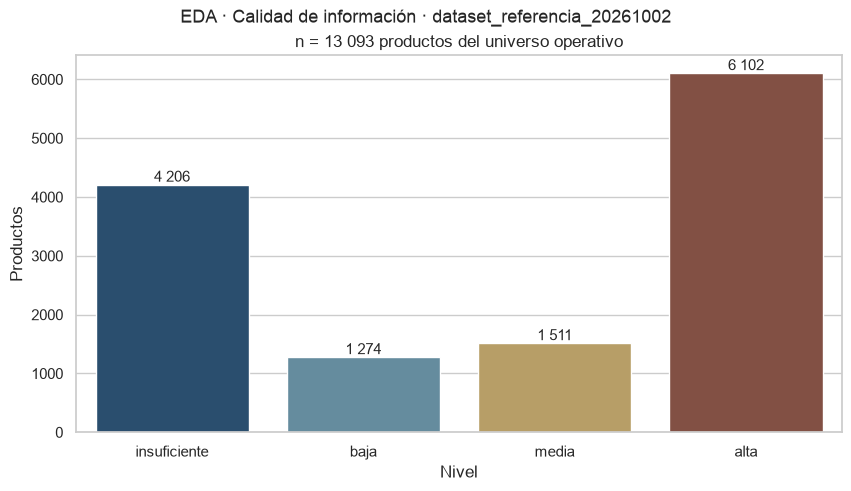

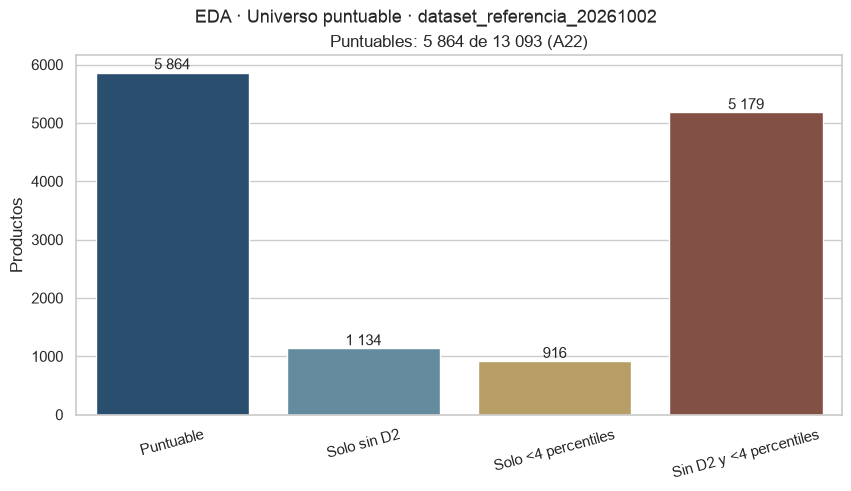

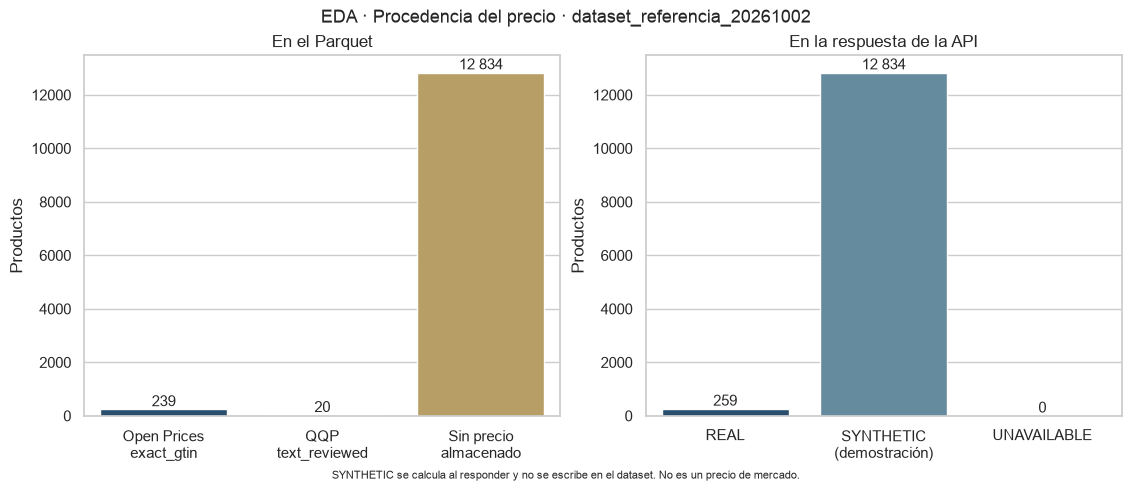

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from IPython.display import display
from nutrimatch.eda.figures import catalogo

sns.set_theme(style="whitegrid", palette="muted", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

raiz = Path.cwd()
ruta = raiz / "datos" / "procesados" / "dataset_referencia_20261002.parquet"
if not ruta.exists():
    ruta = raiz.parent / "datos" / "procesados" / "dataset_referencia_20261002.parquet"
df = pd.read_parquet(ruta)
plt.ioff()
figuras = catalogo(df, dataset_id="dataset_referencia_20261002")
for clave in (
    "eda_calidad_informacion",
    "eda_universo_puntuable",
    "eda_precios_real_sintetico",
):
    display(figuras[clave])
plt.close("all")


## 11. Cierre sobre el universo operativo

El catálogo que alimenta la API es `dataset_referencia_20261002.parquet`: **13 093** productos. El universo puntuable del ranking, con el umbral A22, es de **5 864**.

La calidad de información, indicador derivado y ajeno al score, se reparte así: alta 6 102, insuficiente 4 206, media 1 511 y baja 1 274.

Los precios observados son **259**: 239 de Open Prices por GTIN exacto y 20 de PROFECO QQP por coincidencia de texto revisada. Los 12 834 restantes no tienen precio almacenado. La figura de la derecha cuenta la capa de demostración que la API emite al responder; esos montos no se grafican y no se escriben en el dataset, porque no son precios de mercado.
